In [24]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import onnxruntime as ort
import time
from pathlib import Path
from matplotlib import pyplot as plt

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

print("Imports listos.")

Imports listos.


In [25]:
OJO_IZQUIERDO = [33, 133, 160, 159, 158, 157, 173, 154, 153, 145, 144, 163, 7, 246, 161, 246]
OJO_DERECHO = [362, 263, 387, 386, 385, 384, 398, 381, 380, 374, 373, 390, 249, 466, 388, 466]

BOCA = {
    "izq": 61, "der": 291,
    "sup_ext": 13, "inf_ext": 14,
    "sup1": 82, "inf1": 312,
    "sup2": 87, "inf2": 317,
}

print("Índices definidos.")

Índices definidos.


In [35]:
def recortar_ojo(frame, landmarks, indices, margen=0.35):
    h, w = frame.shape[:2]
    puntos = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in indices])
    x_min, y_min = puntos.min(axis=0)
    x_max, y_max = puntos.max(axis=0)
    ancho, alto = x_max - x_min, y_max - y_min
    x_min -= ancho * margen; x_max += ancho * margen
    y_min -= alto * margen; y_max += alto * margen
    x_min, y_min = max(0, int(x_min)), max(0, int(y_min))
    x_max, y_max = min(w, int(x_max)), min(h, int(y_max))
    return frame[y_min:y_max, x_min:x_max]

def preparar_para_onnx(recorte_bgr):
    img = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0
    media = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    desv = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - media) / desv
    img = img.transpose(2, 0, 1)
    img = np.expand_dims(img, axis=0)
    return img.astype(np.float32)

def calcular_mar(landmarks, frame_shape):
    h, w = frame_shape[:2]
    def punto(idx):
        return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
    horizontal = np.linalg.norm(punto(BOCA["izq"]) - punto(BOCA["der"]))
    vertical1 = np.linalg.norm(punto(BOCA["sup_ext"]) - punto(BOCA["inf_ext"]))
    vertical2 = np.linalg.norm(punto(BOCA["sup1"]) - punto(BOCA["inf1"]))
    vertical3 = np.linalg.norm(punto(BOCA["sup2"]) - punto(BOCA["inf2"]))
    return (vertical1 + vertical2 + vertical3) / (3 * horizontal)

print("Funciones de preprocesamiento listas.")

Funciones de preprocesamiento listas.


In [27]:
opts = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="../models/face_landmarker.task"),
    running_mode=RunningMode.IMAGE,
    num_faces=1,
)
detector = FaceLandmarker.create_from_options(opts)

sesion = ort.InferenceSession("../models/mobilenetv2_ojos.onnx", providers=["CPUExecutionProvider"])
nombre_entrada = sesion.get_inputs()[0].name

print("MediaPipe y modelo ONNX cargados.")

MediaPipe y modelo ONNX cargados.


In [37]:
def procesar_fotograma(frame, detector, sesion, nombre_entrada, umbral_mar=0.6):
    t0 = time.time()
    resultado = {"rostro_detectado": False, "ojo_izq": None, "ojo_der": None,
                 "mar": None, "bostezo": False, "tiempo_ms": None}

    img_mp = mp.Image(image_format=mp.ImageFormat.SRGB,
                       data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    deteccion = detector.detect(img_mp)

    if len(deteccion.face_landmarks) == 0:
        resultado["tiempo_ms"] = (time.time() - t0) * 1000
        return resultado

    landmarks = deteccion.face_landmarks[0]
    resultado["rostro_detectado"] = True

    for clave, indices in [("ojo_izq", OJO_IZQUIERDO), ("ojo_der", OJO_DERECHO)]:
        recorte = recortar_ojo(frame, landmarks, indices, margen=0.35)
        if recorte.size == 0:
            continue
        entrada = preparar_para_onnx(recorte)
        salida = sesion.run(None, {nombre_entrada: entrada})[0]
        probabilidad = 1 / (1 + np.exp(-salida.flatten()[0]))
        resultado[clave] = {"abierto": probabilidad > 0.5, "prob": float(probabilidad)}

    mar = calcular_mar(landmarks, frame.shape)
    resultado["mar"] = mar
    resultado["bostezo"] = mar > umbral_mar

    resultado["tiempo_ms"] = (time.time() - t0) * 1000
    return resultado

print("Función procesar_fotograma lista.")

Función procesar_fotograma lista.


In [45]:
ruta_video = "../data/raw/video_prueba2.mp4"
cap = cv2.VideoCapture(ruta_video)

fps = cap.get(cv2.CAP_PROP_FPS)
total_fotogramas = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video: {fps:.1f} FPS, {total_fotogramas} fotogramas totales")

resultados = []
n = 0
while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break
    r = procesar_fotograma(frame, detector, sesion, nombre_entrada)
    r["fotograma"] = n
    resultados.append(r)
    n += 1

cap.release()
print(f"Procesados {len(resultados)} fotogramas")

Video: 30.0 FPS, 1070 fotogramas totales
Procesados 1070 fotogramas


In [46]:
df_video = pd.DataFrame(resultados)
df_video["ojo_izq_abierto"] = df_video["ojo_izq"].apply(lambda x: x["abierto"] if x else None)
df_video["ojo_der_abierto"] = df_video["ojo_der"].apply(lambda x: x["abierto"] if x else None)
df_video["prob_izq"] = df_video["ojo_izq"].apply(lambda x: x["prob"] if x else np.nan)
df_video["prob_der"] = df_video["ojo_der"].apply(lambda x: x["prob"] if x else np.nan)

print("Tiempo promedio por fotograma (ms):", df_video["tiempo_ms"].mean().round(1))
print("Rostros detectados:", df_video["rostro_detectado"].sum(), "de", len(df_video))
df_video.head(10)

Tiempo promedio por fotograma (ms): 38.5
Rostros detectados: 1070 de 1070


,rostro_detectado,ojo_izq,ojo_der,mar,bostezo,tiempo_ms,fotograma,ojo_izq_abierto,ojo_der_abierto,prob_izq,prob_der
0,True,"{'abierto': True, 'prob': 0.7704605460166931}","{'abierto': True, 'prob': 0.7969350218772888}",0.155906,False,14.289379,0,True,True,0.770461,0.796935
1,True,"{'abierto': True, 'prob': 0.7704605460166931}","{'abierto': True, 'prob': 0.7969350218772888}",0.155890,False,15.008450,1,True,True,0.770461,0.796935
2,True,"{'abierto': True, 'prob': 0.5786473751068115}","{'abierto': True, 'prob': 0.5518391728401184}",0.156172,False,15.156031,2,True,True,0.578647,0.551839
3,True,"{'abierto': True, 'prob': 0.8994521498680115}","{'abierto': True, 'prob': 0.8061026334762573}",0.159084,False,17.027855,3,True,True,0.899452,0.806103
4,True,"{'abierto': True, 'prob': 0.8994521498680115}","{'abierto': True, 'prob': 0.8061026334762573}",0.159152,False,14.524460,4,True,True,0.899452,0.806103
5,True,"{'abierto': True, 'prob': 0.7607534527778625}","{'abierto': True, 'prob': 0.7135804891586304}",0.156058,False,16.030312,5,True,True,0.760753,0.713580
6,True,"{'abierto': True, 'prob': 0.7519552111625671}","{'abierto': True, 'prob': 0.7042763829231262}",0.156232,False,17.050266,6,True,True,0.751955,0.704276
7,True,"{'abierto': False, 'prob': 0.45182284712791443}","{'abierto': True, 'prob': 0.9587182998657227}",0.155575,False,17.031431,7,False,True,0.451823,0.958718
8,True,"{'abierto': True, 'prob': 0.8675237894058228}","{'abierto': True, 'prob': 0.9825817346572876}",0.155025,False,19.034147,8,True,True,0.867524,0.982582
9,True,"{'abierto': True, 'prob': 0.8675237894058228}","{'abierto': True, 'prob': 0.982835590839386}",0.155031,False,17.045498,9,True,True,0.867524,0.982836


In [47]:
VENTANA = 5
df_video["prob_izq_suave"] = df_video["prob_izq"].rolling(VENTANA, center=True, min_periods=1).mean()
df_video["prob_der_suave"] = df_video["prob_der"].rolling(VENTANA, center=True, min_periods=1).mean()
df_video["ojo_izq_abierto_suave"] = df_video["prob_izq_suave"] > 0.5
df_video["ojo_der_abierto_suave"] = df_video["prob_der_suave"] > 0.5

print("Suavizado aplicado.")

Suavizado aplicado.


In [48]:
cerrado_suave = (~df_video["ojo_izq_abierto_suave"]) & (~df_video["ojo_der_abierto_suave"])

rachas_suave = []
contador = 0
for esta_cerrado in cerrado_suave:
    if esta_cerrado:
        contador += 1
    else:
        if contador > 0:
            rachas_suave.append(contador)
        contador = 0
if contador > 0:
    rachas_suave.append(contador)

print("Rachas suavizadas (fotogramas):", sorted(rachas_suave, reverse=True))
print("La más larga, en segundos:", max(rachas_suave)/fps if rachas_suave else 0)

Rachas suavizadas (fotogramas): [14, 8, 6, 5, 2, 2, 2, 2, 1, 1, 1]
La más larga, en segundos: 0.4666666666666667


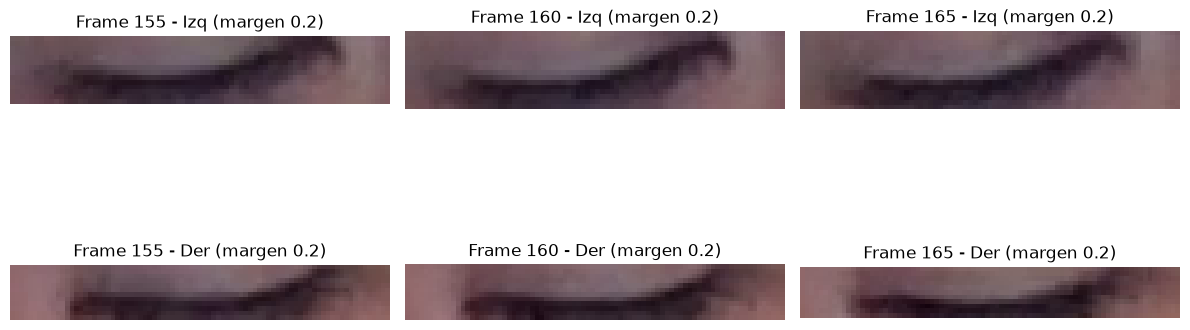

In [49]:
cap = cv2.VideoCapture(ruta_video)
fotogramas_revisar = [155, 160, 165]  # ajusta si tu racha está en otro rango ahora

fig, axes = plt.subplots(2, len(fotogramas_revisar), figsize=(4*len(fotogramas_revisar), 6))
for col, num_frame in enumerate(fotogramas_revisar):
    cap.set(cv2.CAP_PROP_POS_FRAMES, num_frame)
    ok, frame = cap.read()
    if not ok:
        continue
    img_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    resultado = detector.detect(img_mp)
    if len(resultado.face_landmarks) == 0:
        continue
    landmarks = resultado.face_landmarks[0]

    recorte_izq = recortar_ojo(frame, landmarks, OJO_IZQUIERDO, margen=0.2)
    recorte_der = recortar_ojo(frame, landmarks, OJO_DERECHO, margen=0.2)

    axes[0, col].imshow(cv2.cvtColor(recorte_izq, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Frame {num_frame} - Izq (margen 0.2)")
    axes[0, col].axis("off")
    axes[1, col].imshow(cv2.cvtColor(recorte_der, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"Frame {num_frame} - Der (margen 0.2)")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()
cap.release()

In [50]:
cerrado_suave = (~df_video["ojo_izq_abierto_suave"]) & (~df_video["ojo_der_abierto_suave"])
contador, inicio, mejor_inicio, mejor_fin, mejor_largo = 0, None, None, None, 0
for i, c in enumerate(cerrado_suave):
    if c:
        if contador == 0:
            inicio = i
        contador += 1
        if contador > mejor_largo:
            mejor_largo = contador
            mejor_inicio = inicio
            mejor_fin = i
    else:
        contador = 0
print(f"Racha más larga: fotogramas {mejor_inicio} a {mejor_fin} ({mejor_largo} fotogramas, {mejor_largo/fps:.2f}s)")

Racha más larga: fotogramas 748 a 761 (14 fotogramas, 0.47s)


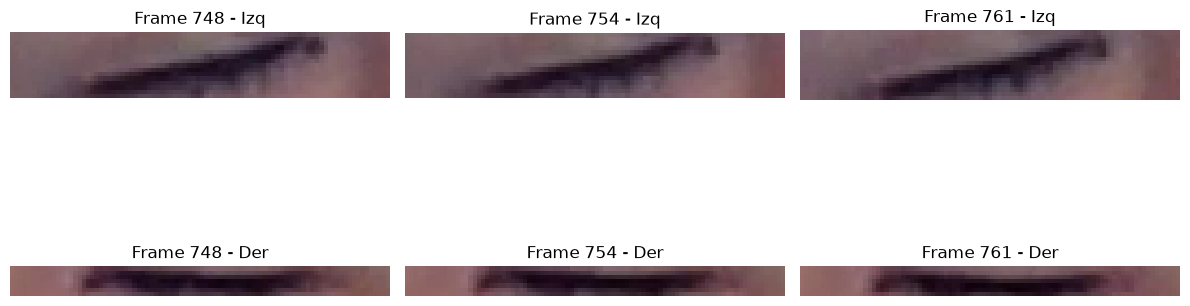

In [52]:
cap = cv2.VideoCapture(ruta_video)
fotogramas_revisar = [748, 754, 761]   # inicio, medio, fin de la racha real

fig, axes = plt.subplots(2, len(fotogramas_revisar), figsize=(4*len(fotogramas_revisar), 6))
for col, num_frame in enumerate(fotogramas_revisar):
    cap.set(cv2.CAP_PROP_POS_FRAMES, num_frame)
    ok, frame = cap.read()
    if not ok:
        continue
    img_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    resultado = detector.detect(img_mp)
    if len(resultado.face_landmarks) == 0:
        continue
    landmarks = resultado.face_landmarks[0]

    recorte_izq = recortar_ojo(frame, landmarks, OJO_IZQUIERDO, margen=0.35)
    recorte_der = recortar_ojo(frame, landmarks, OJO_DERECHO, margen=0.35)

    axes[0, col].imshow(cv2.cvtColor(recorte_izq, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Frame {num_frame} - Izq")
    axes[0, col].axis("off")
    axes[1, col].imshow(cv2.cvtColor(recorte_der, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"Frame {num_frame} - Der")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()
cap.release()

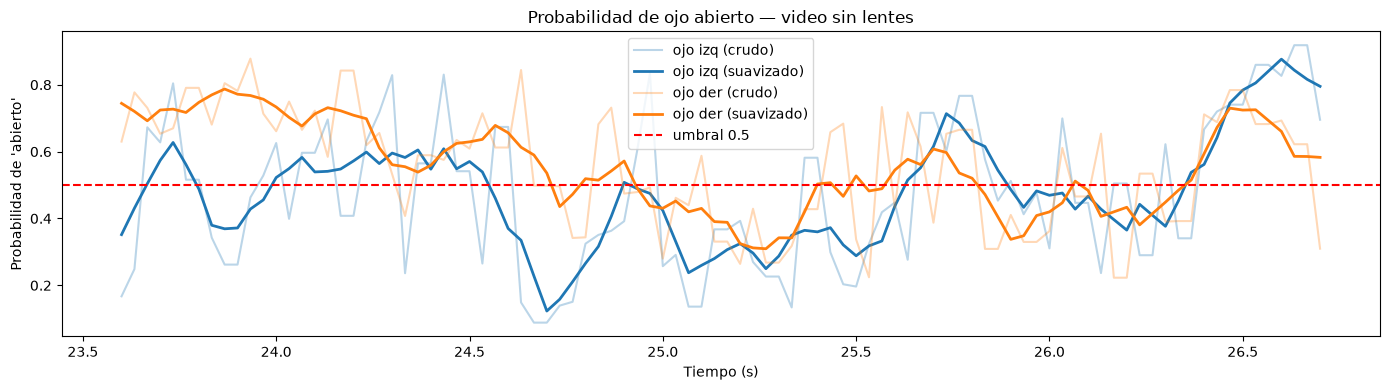

In [53]:
sub = df_video[(df_video["fotograma"] >= 748-40) & (df_video["fotograma"] <= 761+40)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub["fotograma"]/fps, sub["prob_izq"], alpha=0.3, label="ojo izq (crudo)", color="C0")
ax.plot(sub["fotograma"]/fps, sub["prob_izq_suave"], label="ojo izq (suavizado)", color="C0", linewidth=2)
ax.plot(sub["fotograma"]/fps, sub["prob_der"], alpha=0.3, label="ojo der (crudo)", color="C1")
ax.plot(sub["fotograma"]/fps, sub["prob_der_suave"], label="ojo der (suavizado)", color="C1", linewidth=2)
ax.axhline(0.5, color="red", linestyle="--", label="umbral 0.5")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Probabilidad de 'abierto'")
ax.legend()
ax.set_title("Probabilidad de ojo abierto — video sin lentes")
plt.tight_layout()
plt.show()

In [55]:
def detectar_microsuenos(df_video, fps, segundos_umbral=1.5):
    fotogramas_umbral = int(fps * segundos_umbral)
    cerrado = (df_video["ojo_izq_abierto"] == False) & (df_video["ojo_der_abierto"] == False)

    eventos = []
    contador = 0
    inicio = None
    for i, esta_cerrado in enumerate(cerrado):
        if esta_cerrado:
            if contador == 0:
                inicio = i
            contador += 1
        else:
            if contador >= fotogramas_umbral:
                eventos.append({"inicio_fotograma": inicio, "fin_fotograma": i - 1,
                                 "duracion_seg": contador / fps})
            contador = 0
    # revisar si el video termina con los ojos aún cerrados
    if contador >= fotogramas_umbral:
        eventos.append({"inicio_fotograma": inicio, "fin_fotograma": len(cerrado) - 1,
                         "duracion_seg": contador / fps})
    return eventos

eventos = detectar_microsuenos(df_video, fps)
print(f"Microsueños detectados: {len(eventos)}")
for e in eventos:
    print(f"  Fotogramas {e['inicio_fotograma']}-{e['fin_fotograma']} | duración: {e['duracion_seg']:.2f}s")

Microsueños detectados: 0
